# 05 - Deep Learning for Sarcasm Detection

## Objective

This notebook implements deep learning models for sarcasm detection using multiple datasets:

- SemEval Irony Dataset
- Reddit Sarcasm Dataset
- News Headlines Dataset

The main goals are:

- Build a reusable LSTM pipeline
- Train and evaluate deep learning models on multiple datasets
- Compare performance across different sarcasm domains
- Prepare the workflow for transformer-based models such as BERT

## Deep Learning Workflow

The implemented pipeline includes:

1. Dataset Loading
2. Tokenization
3. Sequence Padding
4. LSTM Model Construction
5. Model Training
6. Performance Evaluation
7. Cross-Dataset Comparison

## 1. Import Libraries

The required libraries for:
- data handling
- visualization
- TensorFlow deep learning
- evaluation metrics

are imported in this section.

In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

## 2. Load All Preprocessed Datasets

The preprocessed datasets for sarcasm detection are loaded in this section.

Datasets used:
- SemEval Irony Dataset
- Reddit Sarcasm Dataset
- News Headlines Dataset

Each dataset contains:
- `text` → input text
- `label` → sarcasm label
  - `0` → Non-sarcastic
  - `1` → Sarcastic

In [2]:
# ===============================
# LOAD ALL DATASETS
# ===============================

# SemEval
semeval_train = pd.read_csv("../Data/processed/semeval_train.csv")
semeval_test = pd.read_csv("../Data/processed/semeval_test.csv")

# Reddit
reddit_train = pd.read_csv("../Data/processed/reddit_train.csv")
reddit_test = pd.read_csv("../Data/processed/reddit_test.csv")

# Reduce Reddit immediately
reddit_train = reddit_train.sample(20000,random_state=42)
reddit_test = reddit_test.sample(5000,random_state=42)

# Headlines
headlines_train = pd.read_csv("../Data/processed/headlines_train.csv")
headlines_test = pd.read_csv("../Data/processed/headlines_test.csv")


# Display dataset shapes
print("SemEval Train Shape:", semeval_train.shape)
print("SemEval Test Shape:", semeval_test.shape)

print("\nReddit Train Shape:", reddit_train.shape)
print("Reddit Test Shape:", reddit_test.shape)

print("\nHeadlines Train Shape:", headlines_train.shape)
print("Headlines Test Shape:", headlines_test.shape)

SemEval Train Shape: (3052, 2)
SemEval Test Shape: (764, 2)

Reddit Train Shape: (20000, 4)
Reddit Test Shape: (5000, 4)

Headlines Train Shape: (22895, 2)
Headlines Test Shape: (5724, 2)


## 3. Inspect Reddit Dataset Structure

The Reddit dataset is inspected to verify the availability of contextual information required for the context-based sarcasm detection experiment.

In [3]:
# ===============================
# CHECK REDDIT DATASET COLUMNS
# ===============================

print(reddit_train.columns)

reddit_train.head()

Index(['label', 'text', 'context', 'subreddit'], dtype='object')


,label,text,context,subreddit
376986,1,good luck getting an invite for the discount c...,oneplus lowers prices on all smartphones.,Android
282003,0,talk about a culture that should not have acce...,saudis parade nuclear missiles for the first t...,worldnews
396899,1,"wow, i didn't realize there was anyone under t...","this isn't even about south florida, this is a...",FloridaMan
759494,0,"beat me to it, you bastard.",it's also a lot of people fuckin seriously.,AskReddit
12785,0,pastelle is pretty lame tbh..,if he retakes pastelle away from ian and makes...,streetwear


## 4. Create Contextual Reddit Variants

Two Reddit dataset variants are created for the contextual sarcasm detection experiment:

1. **Without Context**
   - uses only the reply text

2. **With Context**
   - combines parent context and reply text

This enables evaluation of whether contextual information improves sarcasm detection performance.

In [4]:
# ===============================
# CREATE REDDIT CONTEXT VARIANTS
# ===============================

# Without context
reddit_train_no_context = reddit_train.copy()
reddit_test_no_context = reddit_test.copy()

# With context
reddit_train_with_context = reddit_train.copy()
reddit_test_with_context = reddit_test.copy()


# Combine context + reply text
reddit_train_with_context["combined_text"] = (
    reddit_train_with_context["context"].astype(str)
    + " [SEP] "
    + reddit_train_with_context["text"].astype(str)
)

reddit_test_with_context["combined_text"] = (
    reddit_test_with_context["context"].astype(str)
    + " [SEP] "
    + reddit_test_with_context["text"].astype(str)
)


print("No-context Reddit sample:\n")
print(reddit_train_no_context["text"].iloc[0])

print("\nWith-context Reddit sample:\n")
print(reddit_train_with_context["combined_text"].iloc[0])

No-context Reddit sample:

good luck getting an invite for the discount coupon.

With-context Reddit sample:

oneplus lowers prices on all smartphones. [SEP] good luck getting an invite for the discount coupon.


## 5. Organize Datasets

The datasets are organized into a dictionary structure for reusable LSTM experiments.

For Reddit, two variants are included:

- Reddit without contextual information
- Reddit with contextual information

This enables direct evaluation of the impact of conversational context on sarcasm detection.

In [5]:
# ===============================
# ORGANIZE DATASETS
# ===============================

datasets = {

    # RQ1 datasets
    "SemEval": (
        semeval_train,
        semeval_test
    ),

    "Headlines": (
        headlines_train,
        headlines_test
    ),

    # RQ2 experiments
    "Reddit_No_Context": (
        reddit_train_no_context,
        reddit_test_no_context
    ),

    "Reddit_With_Context": (
        reddit_train_with_context,
        reddit_test_with_context
    )
}


print("Datasets Loaded:\n")

for dataset_name in datasets.keys():
    print(dataset_name)

Datasets Loaded:

SemEval
Headlines
Reddit_No_Context
Reddit_With_Context


## 6. Tokenization Setup

Deep learning models cannot process raw text directly. Therefore, the text must first be converted into numerical representations.

Tokenization:
- converts words into integer indices
- creates a vocabulary from the training data
- prepares text for sequence-based neural networks such as LSTM

Key parameters:
- `VOCAB_SIZE` → maximum vocabulary size
- `MAX_LENGTH` → maximum sequence length
- `OOV Token` → handles unknown words

In [5]:
# ===============================
# TOKENIZATION PARAMETERS
# ===============================

VOCAB_SIZE = 10000
MAX_LENGTH = 50

print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Sequence Length:", MAX_LENGTH)

Vocabulary Size: 10000
Maximum Sequence Length: 50


## 7. Create Reusable Text Processing Function

A reusable preprocessing function is created to:

1. Tokenize text
2. Convert text into sequences
3. Apply padding to equalize sequence lengths

This function allows the same pipeline to be reused across all datasets.

In [6]:
# ===============================
# TOKENIZATION + PADDING FUNCTION
# ===============================

def prepare_sequences(X_train, X_test):
    
    # Initialize tokenizer
    tokenizer = Tokenizer(
        num_words=VOCAB_SIZE,
        oov_token="<OOV>"
    )

    # Fit tokenizer on training data
    tokenizer.fit_on_texts(X_train)

    # Convert text to sequences
    train_sequences = tokenizer.texts_to_sequences(X_train)
    test_sequences = tokenizer.texts_to_sequences(X_test)

    # Apply padding
    X_train_pad = pad_sequences(
        train_sequences,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    X_test_pad = pad_sequences(
        test_sequences,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    return tokenizer, X_train_pad, X_test_pad

## 8. Prepare All Datasets for LSTM

In this step:

- text data is extracted
- labels are separated
- tokenization is applied
- padded numerical sequences are generated

The processed datasets are stored in a dictionary structure for reusable LSTM training.

In [8]:
# ===============================
# PREPARE ALL DATASETS
# ===============================

processed_data = {}

for dataset_name, (train_df, test_df) in datasets.items():

    print(f"\nProcessing {dataset_name} Dataset...")

    # ==========================================
    # EXTRACT FEATURES AND LABELS
    # ==========================================

    # Use contextual text for Reddit context experiment
    if dataset_name == "Reddit_With_Context":

        X_train = train_df["combined_text"].astype(str)
        X_test = test_df["combined_text"].astype(str)

    else:

        X_train = train_df["text"].astype(str)
        X_test = test_df["text"].astype(str)

    y_train = train_df["label"]
    y_test = test_df["label"]

    # ==========================================
    # TOKENIZATION + PADDING
    # ==========================================

    tokenizer, X_train_pad, X_test_pad = prepare_sequences(
        X_train,
        X_test
    )

    # ==========================================
    # STORE PROCESSED DATA
    # ==========================================

    processed_data[dataset_name] = {
        "X_train": X_train_pad,
        "X_test": X_test_pad,
        "y_train": y_train,
        "y_test": y_test,
        "tokenizer": tokenizer
    }

    print("Training Shape:", X_train_pad.shape)
    print("Testing Shape:", X_test_pad.shape)

NameError: name 'datasets' is not defined

## 9. Build Reusable LSTM Model

A reusable LSTM architecture is created for sarcasm detection.

### Architecture

The model consists of:

1. Embedding Layer
   - converts integer tokens into dense vector representations

2. LSTM Layer
   - learns sequential and contextual information from text

3. Dropout Layer
   - reduces overfitting

4. Dense Output Layer
   - performs binary sarcasm classification

### Output

- `0` → Non-sarcastic
- `1` → Sarcastic

In [12]:
# ===============================
# BUILD LSTM MODEL
# ===============================

def build_lstm_model():

    model = Sequential([

        # Embedding Layer
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=MAX_LENGTH
        ),

        # LSTM Layer
        LSTM(64),

        # Dropout for regularization
        Dropout(0.5),

        # Dense hidden layer
        Dense(64, activation="relu"),

        Dropout(0.3),

        # Output layer
        Dense(1, activation="sigmoid")
    ])

    # Compile model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 10. Train LSTM Models on All Datasets

The reusable LSTM model is trained separately on:

- SemEval
- Reddit
- News Headlines

### Training Configuration

- Optimizer: Adam
- Loss Function: Binary Crossentropy
- Epochs: 10
- Batch Size: 32

### Early Stopping

Early stopping is used to:
- monitor validation loss
- reduce overfitting
- restore the best model weights

In [13]:
# ===============================
# TOKENIZATION PARAMETERS
# ===============================

VOCAB_SIZE = 20000
MAX_LENGTH = 100


# ===============================
# BUILD IMPROVED LSTM MODEL
# ===============================

def build_lstm_model():

    model = Sequential([

        # Embedding Layer
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128
        ),

        # BiLSTM Layer
        Bidirectional(
            LSTM(
                128,
                return_sequences=False
            )
        ),

        # Dropout Layer
        Dropout(0.3),

        # Dense Layer
        Dense(64, activation="relu"),

        Dropout(0.2),

        # Output Layer
        Dense(1, activation="sigmoid")
    ])

    # Compile model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ===============================
# REBUILD DATASET DICTIONARY
# ===============================

datasets = {

    # SemEval
    "SemEval": (
        semeval_train,
        semeval_test
    ),

    # Headlines
    "Headlines": (
        headlines_train,
        headlines_test
    ),

    # Reddit without context
    "Reddit_No_Context": (
        reddit_train_no_context,
        reddit_test_no_context
    ),

    # Reddit with context
    "Reddit_With_Context": (
        reddit_train_with_context,
        reddit_test_with_context
    )
}


# ===============================
# REPROCESS ALL DATASETS
# ===============================

processed_data = {}

for dataset_name, (train_df, test_df) in datasets.items():

    print(f"\nProcessing {dataset_name} Dataset...")

    # ==========================================
    # FEATURES AND LABELS
    # ==========================================

    # Use contextual text for Reddit context experiment
    if dataset_name == "Reddit_With_Context":

        X_train = train_df["combined_text"].astype(str)
        X_test = test_df["combined_text"].astype(str)

    else:

        X_train = train_df["text"].astype(str)
        X_test = test_df["text"].astype(str)

    y_train = train_df["label"]
    y_test = test_df["label"]

    # ==========================================
    # TOKENIZATION + PADDING
    # ==========================================

    tokenizer, X_train_pad, X_test_pad = prepare_sequences(
        X_train,
        X_test
    )

    # ==========================================
    # STORE PROCESSED DATA
    # ==========================================

    processed_data[dataset_name] = {
        "X_train": X_train_pad,
        "X_test": X_test_pad,
        "y_train": y_train,
        "y_test": y_test,
        "tokenizer": tokenizer
    }

    print("Training Shape:", X_train_pad.shape)
    print("Testing Shape:", X_test_pad.shape)


# ===============================
# TRAIN LSTM MODELS
# ===============================

trained_models = {}
training_history = {}

for dataset_name, data in processed_data.items():

    print(f"\nTraining LSTM on {dataset_name} Dataset...\n")

    # Extract processed data
    X_train = data["X_train"]
    y_train = data["y_train"]

    # Build model
    model = build_lstm_model()

    # Early stopping
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    # Train model
    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    # Store trained models
    trained_models[dataset_name] = model
    training_history[dataset_name] = history

    print(f"\nCompleted Training for {dataset_name}\n")


Processing SemEval Dataset...
Training Shape: (3052, 100)
Testing Shape: (764, 100)

Processing Headlines Dataset...
Training Shape: (22895, 100)
Testing Shape: (5724, 100)

Processing Reddit_No_Context Dataset...
Training Shape: (20000, 100)
Testing Shape: (5000, 100)

Processing Reddit_With_Context Dataset...
Training Shape: (20000, 100)
Testing Shape: (5000, 100)

Training LSTM on SemEval Dataset...

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 167ms/step - accuracy: 0.5954 - loss: 0.6795 - val_accuracy: 0.5556 - val_loss: 0.6863
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.7793 - loss: 0.4627 - val_accuracy: 0.8301 - val_loss: 0.4227
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 163ms/step - accuracy: 0.9472 - loss: 0.1491 - val_accuracy: 0.8824 - val_loss: 0.2988
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - accuracy: 0.9832 - loss: 0.0573 - val_accuracy: 0.8529 - val_loss: 0.4215
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step - accuracy: 0.9891 - lo

## 11. Evaluate LSTM Models

The trained LSTM models are evaluated on the test datasets using:

- Accuracy
- F1-score
- Classification Report
- Confusion Matrix

The evaluation helps compare sarcasm detection performance across different datasets.

In [12]:
# ===============================
# EVALUATE ALL MODELS
# ===============================

results = []

for dataset_name, data in processed_data.items():

    print(f"\nEvaluating {dataset_name} Model...\n")

    # Load test data
    X_test = data["X_test"]
    y_test = data["y_test"]

    # Load trained model
    model = trained_models[dataset_name]

    # Predict probabilities
    y_pred_prob = model.predict(X_test)

    # Convert probabilities to binary predictions
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append({
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "F1-Score": f1
    })

    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


Evaluating SemEval Model...

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
Accuracy: 0.8757
F1-Score: 0.8857

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.79      0.86       383
           1       0.82      0.97      0.89       381

    accuracy                           0.88       764
   macro avg       0.89      0.88      0.87       764
weighted avg       0.89      0.88      0.87       764


Evaluating Headlines Model...

179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step
Accuracy: 0.8667
F1-Score: 0.8628

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.85      0.87      2997
           1       0.85      0.88      0.86      2727

    accuracy                           0.87      5724
   macro avg       0.87      0.87      0.87      5724
weighted avg       0.87      0.87      0.87      5724


Evaluating Reddit_No_Context Model...

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step
A

## Evaluation Results and Discussion

The improved BiLSTM model achieved strong performance on the SemEval and News Headlines datasets, with accuracies of 87.57% and 86.67% respectively. These results indicate that the model was effective in learning sarcasm and irony patterns from structured and shorter text samples.

The Reddit dataset remained more challenging due to its conversational and informal nature. The Reddit_No_Context experiment achieved an accuracy of 67.20% and an F1-score of 66.39%, showing moderate sarcasm detection capability on social media discussions.

For the contextual sarcasm detection experiment, the Reddit_With_Context model achieved slightly lower performance compared to the no-context version. Although contextual information was expected to improve sarcasm understanding, the additional parent-comment text may have introduced noise and increased sequence complexity for the BiLSTM model. This suggests that simple context concatenation is not always beneficial for LSTM-based sarcasm detection systems.

Overall, the results demonstrate that the BiLSTM model performs effectively for same-domain sarcasm and irony detection, while conversational Reddit sarcasm remains more difficult due to contextual and linguistic complexity.

## 12. Confusion Matrix Visualization

Confusion matrices are used to visualize the prediction behavior of the LSTM models.

They help identify:
- correctly classified samples
- misclassified samples
- class prediction bias

Rows represent actual labels, while columns represent predicted labels.


Confusion Matrix - SemEval

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


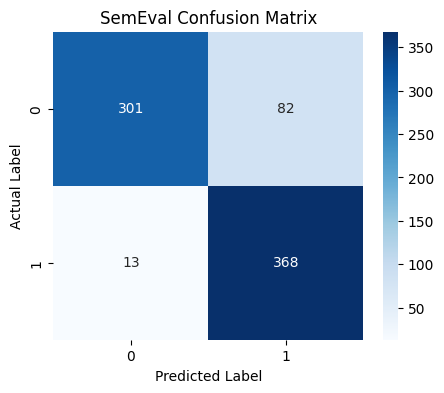


Confusion Matrix - Headlines

179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step


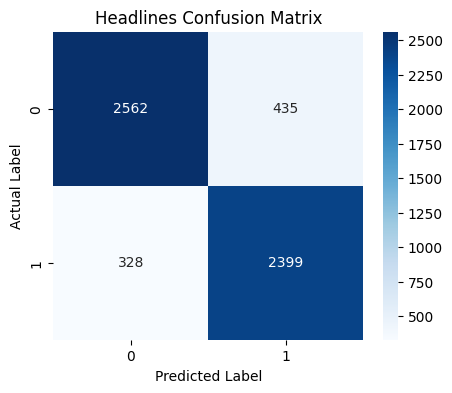


Confusion Matrix - Reddit_No_Context

157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step


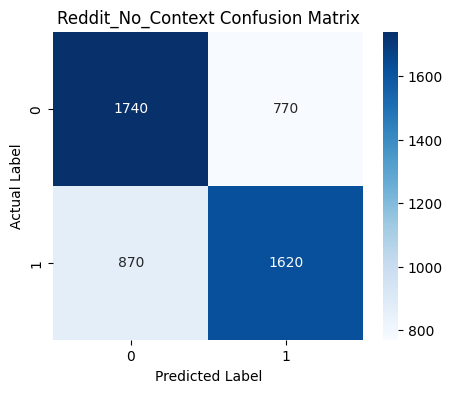


Confusion Matrix - Reddit_With_Context

157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step


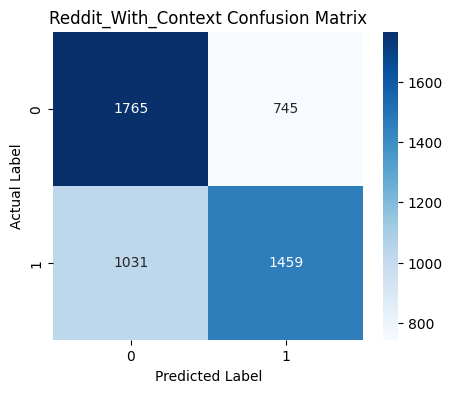

In [13]:
# ===============================
# CONFUSION MATRICES
# ===============================

for dataset_name, data in processed_data.items():

    print(f"\nConfusion Matrix - {dataset_name}\n")

    # Test data
    X_test = data["X_test"]
    y_test = data["y_test"]

    # Model
    model = trained_models[dataset_name]

    # Predictions
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()

## Confusion Matrix Analysis

The confusion matrices provide a detailed view of the prediction performance of the BiLSTM model across all datasets.

For the SemEval dataset, the model correctly classified most sarcastic and non-sarcastic samples, with only a small number of misclassifications. This indicates strong irony detection capability and balanced learning between both classes.

The Headlines dataset also showed strong classification performance, with a high number of correct predictions for both sarcastic and non-sarcastic headlines. The confusion matrix demonstrates that the model generalized well on structured satirical news text.

The Reddit_No_Context experiment produced moderate classification performance. Although the model successfully identified many sarcastic and non-sarcastic comments, a relatively larger number of false positives and false negatives were observed due to the conversational and noisy nature of Reddit discussions.

For the Reddit_With_Context experiment, the confusion matrix showed increased misclassification compared to the no-context version. In particular, the number of sarcastic comments incorrectly classified as non-sarcastic increased noticeably. This suggests that simply concatenating contextual information introduced additional noise and complexity for the BiLSTM model, leading to reduced classification performance.

Overall, the confusion matrices confirm that the BiLSTM model performed best on the SemEval and Headlines datasets, while Reddit sarcasm detection remained more challenging due to conversational complexity and contextual ambiguity.

## 13. Cross-Domain Experiment Setup

To evaluate the generalization capability of the BiLSTM model across domains, cross-domain experiments are performed. In these experiments, the model is trained on one dataset and evaluated on a different dataset.

The experiments include:

- Reddit → Headlines
- Headlines → Reddit
- Reddit → SemEval
- SemEval → Reddit
- Headlines → SemEval
- SemEval → Headlines

These experiments help determine whether sarcasm and irony patterns learned in one domain can transfer effectively to another domain.

In [16]:
# ===============================
# CROSS-DOMAIN TRAINING
# ===============================

cross_domain_results = []

for train_dataset, test_dataset in cross_domain_pairs:

    print("\n" + "="*60)
    print(f"TRAIN: {train_dataset}")
    print(f"TEST : {test_dataset}")
    print("="*60)

    # ==========================================
    # TRAIN DATA
    # ==========================================

    X_train = processed_data[train_dataset]["X_train"]
    y_train = processed_data[train_dataset]["y_train"]

    # ==========================================
    # TEST DATA
    # ==========================================

    X_test = processed_data[test_dataset]["X_test"]
    y_test = processed_data[test_dataset]["y_test"]

    # ==========================================
    # BUILD MODEL
    # ==========================================

    model = build_lstm_model()

    # ==========================================
    # EARLY STOPPING
    # ==========================================

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    # ==========================================
    # TRAIN MODEL
    # ==========================================

    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    # ==========================================
    # PREDICTIONS
    # ==========================================

    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # ==========================================
    # EVALUATION
    # ==========================================

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    cross_domain_results.append({
        "Train Dataset": train_dataset,
        "Test Dataset": test_dataset,
        "Accuracy": accuracy,
        "F1-Score": f1
    })

    # Print results
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


TRAIN: Reddit_No_Context
TEST : Headlines
Epoch 1/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 101s 167ms/step - accuracy: 0.6370 - loss: 0.6316 - val_accuracy: 0.6485 - val_loss: 0.6243
Epoch 2/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 141s 166ms/step - accuracy: 0.7609 - loss: 0.4978 - val_accuracy: 0.6285 - val_loss: 0.7263
Epoch 3/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 143s 168ms/step - accuracy: 0.8623 - loss: 0.3231 - val_accuracy: 0.6205 - val_loss: 0.8358
Epoch 4/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 141s 165ms/step - accuracy: 0.9208 - loss: 0.1978 - val_accuracy: 0.6195 - val_loss: 1.1221
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

Accuracy: 0.5381
F1-Score: 0.4533

Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.66      0.60      2997
           1       0.52      0.40      0.45      2727

    accuracy                           0.54      5724
   macro avg       0.53      0.53      0.53      5724
weighted avg       0.53      0.54      0.53      5724


## Cross-Domain Evaluation Results

The cross-domain experiments demonstrated a significant decrease in BiLSTM performance when models were evaluated on datasets different from their training domain.

While same-domain experiments achieved strong performance, cross-domain accuracies dropped to approximately 47–54% across most experiments. This indicates that the BiLSTM model learned domain-specific sarcasm and irony patterns rather than generalized representations.

The results suggest that sarcasm expressions vary considerably across domains such as conversational Reddit discussions, satirical news headlines, and Twitter irony datasets. Differences in vocabulary, sentence structure, writing style, and contextual usage reduced the transferability of learned features between datasets.

Overall, the findings show that cross-domain sarcasm detection remains a challenging problem for BiLSTM architectures and highlights the importance of more context-aware transformer-based models such as BERT.

## 9. Cross-Domain Evaluation Results

The following table summarizes the cross-domain performance of the BiLSTM model. In each experiment, the model was trained on one dataset and evaluated on a different dataset to assess its generalization capability across domains.

In [17]:
# ===============================
# CROSS-DOMAIN RESULTS TABLE
# ===============================

cross_domain_df = pd.DataFrame(cross_domain_results)

cross_domain_df

,Train Dataset,Test Dataset,Accuracy,F1-Score
0,Reddit_No_Context,Headlines,0.538085,0.453267
1,Headlines,Reddit_No_Context,0.510200,0.461640
2,Reddit_No_Context,SemEval,0.497382,0.525926
3,SemEval,Reddit_No_Context,0.501800,0.394948
4,Headlines,SemEval,0.471204,0.398810
5,SemEval,Headlines,0.494759,0.335478


# Repeated LSTM Experiments for Statistical Analysis

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np

In [16]:
NUM_RUNS = 10

lstm_results = []

print("Starting Repeated Experiments...")

Starting Repeated Experiments...


In [ ]:
for dataset_name, data in processed_data.items():

    print("\n" + "="*60)
    print(f"DATASET: {dataset_name}")
    print("="*60)

    X_train = data["X_train"]
    X_test = data["X_test"]

    y_train = data["y_train"]
    y_test = data["y_test"]

    for run in range(NUM_RUNS):

        print(f"\nRun {run+1}")

        # Build fresh model
        model = build_lstm_model()

        # Train
        history = model.fit(
            X_train,
            y_train,
            epochs=15,
            batch_size=32,
            validation_split=0.1,
            verbose=0
        )

        # Predict
        y_pred_prob = model.predict(
            X_test,
            verbose=0
        )

        y_pred = (
            y_pred_prob > 0.5
        ).astype(int)

        # Metrics
        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred
        )

        recall = recall_score(
            y_test,
            y_pred
        )

        f1 = f1_score(
            y_test,
            y_pred
        )

        lstm_results.append({

            "Dataset": dataset_name,

            "Run": run + 1,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1": f1
        })

        print(
            f"Accuracy={accuracy:.4f} | "
            f"F1={f1:.4f}"
        )